Compare classification performance through the different subsets of features across multiple years


In [9]:
import sys
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

import ee
ee.Initialize(project='mapbiomas-india')

# Add parent directory to path to import the module
sys.path.append('..')
from multi_parameters_runs_and_analysis.feature_selection_module import EEFeatureSelectionModule

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

In [10]:
# Load dataset metadata
classwise_samples_scaled_2k_10k = pd.read_csv('data/classwise_samples_scaled_2k_10k.csv')
runs_analysis_df = pd.read_csv('data/groupwise_runs_default_and_scaled_samples.csv')
region_numbers_df = pd.read_csv('data/regions_area.csv')
legends_df = pd.read_csv('data/class_legend.csv')

# Identify the top-performing region from previous analysis
test_region = runs_analysis_df.sort_values(by=['f1_weighted'], ascending=False).iloc[0]
region_code = test_region['region']
region_id = int(region_numbers_df[region_numbers_df['region_code'] == region_code]['region_id'].iloc[0])
sample_version_in = int(test_region['sample_version'])
n_trees = int(test_region['n_trees'])

# Prepare class balancing sample dictionary
balance_samples = list(map(list, dict(zip(
    classwise_samples_scaled_2k_10k['l2_code'],
    classwise_samples_scaled_2k_10k[region_code]
)).items()))

print(f"Selected Region: {region_code} (ID: {region_id})")
print(f"Sample Version: v{sample_version_in} | Random Forest Trees: {n_trees}")

Selected Region: DES (ID: 3)
Sample Version: v7 | Random Forest Trees: 50


In [11]:
YEARS = [1995, 2005, 2015, 2024]

In [21]:
scenariowise_perf_df = pd.DataFrame(columns=['region','sample_version','year', 'features', 'n_trees','f1_weighted', 'accuracy'])

In [ ]:
top_20_features = \
['pri_median',
 'slope',
 'pri_median_wet',
 'pri_median_dry',
 'green_median_texture',
 'blue_median',
 'red_median_dry',
 'ndvi_median_dry',
 'blue_median_wet',
 'nir_stdDev',
 'swir1_min',
 'cai_median_dry',
 'red_median',
 'green_median_wet',
 'swir1_median_dry',
 'red_stdDev',
 'ndwi_median_dry',
 'green_min',
 'gcvi_median_dry',
 'cai_median'] #median

# ['pri_median',
#  'pri_median_dry',
#  'green_median_texture',
#  'pri_median_wet',
#  'slope',
#  'ndvi_median_dry',
#  'blue_median_wet',
#  'red_median_dry',
#  'blue_median',
#  'red_median',
#  'green_min',
#  'cai_median_dry',
#  'nir_stdDev',
#  'cai_median',
#  'blue_median_dry',
#  'swir1_min',
#  'red_stdDev',
#  'green_median',
#  'blue_min',
#  'savi_median_dry'] #mean

In [14]:
correlated_features_filtered = \
['cai_median',
 'cai_median_dry',
 'cai_stdDev',
 'cloud_min',
 'green_median_texture',
 'ndfi_min',
 'ndvi_median_dry',
 'ndwi_amp',
 'ndwi_median_dry',
 'nir_median',
 'nir_median_wet',
 'npv_median_wet',
 'npv_min',
 'pri_median',
 'pri_median_dry',
 'pri_median_wet',
 'sefi_median_dry',
 'sefi_stdDev',
 'shade_amp',
 'shade_min',
 'slope',
 'soil_amp']

In [ ]:
# regions = ['HIM', 'IGP', 'DES', 'PEN', 'NEI', 'WGR', 'ICR']
# region_id_map = {'HIM': 1, 'IGP': 2, 'DES': 3, 'PEN': 4, 'NEI': 5, 'WGR': 6, 'ICR': 7}
# years = [2018]

# # Define regional sample versions 
# # (Update these values with your actual version strings)
# sample_version_map = {
#     'HIM': '4', 
#     'IGP': '5', 
#     'DES': '7', 
#     'PEN': '5', 
#     'NEI': '5', 
#     'WGR': '3', 
#     'ICR': '4'
# }

# param_grid = {
#     'features': ['all', 'static_16','top_20','corr_filtered'],
#     'minLeafPopulation' : [5],

# }

Scenario 1: All features

In [16]:
scenario = 'all'

In [19]:
run_logs = []

In [ ]:
for yr in YEARS:
    # logging.info(f"====== PROCESSING TEMPORAL SNAPSHOT: {yr} ======")
    
    # 1. Initialize Module & Balance Data
    selector = EEFeatureSelectionModule(
        region_id=region_id, 
        year=yr, 
        sample_version_in=sample_version_in, 
        number_of_trees=n_trees
    )
    _ = selector.load_and_balance_data(balance_samples=balance_samples)


    if scenario == 'all':
        all_features = selector.training_partition.first().propertyNames()
        features_to_drop = ['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion']
        features_list = ee.List(all_features).removeAll(ee.List(features_to_drop)).getInfo()
    # else:
    #             features_list = ee_module.default_bands
    trained_classifier, accuracy, f1_weighted, y_true, y_pred = selector.evaluate_model(features_list)

    run_logs.append({
        'region': region_id,
        'year': yr,
        'sample_version': sample_version_in,
        'features': scenario,
        'n_trees': n_trees,
        # 'features': params['features'],
        'accuracy': accuracy,
        'f1_weighted': f1_weighted
    })

Calculating Level 1 class distributions (this may take a moment)...


Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...


In [23]:
scenariowise_perf_df = pd.concat([scenariowise_perf_df,pd.DataFrame(run_logs)], ignore_index=True)

In [24]:
scenariowise_perf_df

,region,sample_version,year,features,n_trees,f1_weighted,accuracy
0,NaN,7,1995,all,50,0.905772,0.906355
1,NaN,7,2005,all,50,0.932824,0.933157
2,NaN,7,2015,all,50,0.950504,0.950298
3,NaN,7,2024,all,50,0.941234,0.941845


Scenario 2: Static 16 features

In [25]:
scenario = 'static_16'

In [26]:
for yr in YEARS:
    # logging.info(f"====== PROCESSING TEMPORAL SNAPSHOT: {yr} ======")
    
    # 1. Initialize Module & Balance Data
    selector = EEFeatureSelectionModule(
        region_id=region_id, 
        year=yr, 
        sample_version_in=sample_version_in, 
        number_of_trees=n_trees
    )
    _ = selector.load_and_balance_data(balance_samples=balance_samples)

    if scenario == 'all':
        all_features = selector.training_partition.first().propertyNames()
        features_to_drop = ['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion']
        features_list = ee.List(all_features).removeAll(ee.List(features_to_drop)).getInfo()
    elif scenario == 'static_16':
        features_list = selector.default_bands

    trained_classifier, accuracy, f1_weighted, y_true, y_pred = selector.evaluate_model(features_list)

    run_logs.append({
        'region': region_id,
        'year': yr,
        'sample_version': sample_version_in,
        'features': scenario,
        'n_trees': n_trees,
        # 'features': params['features'],
        'accuracy': accuracy,
        'f1_weighted': f1_weighted
    })

Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...


In [30]:
scenariowise_perf_df = pd.DataFrame(run_logs)
scenariowise_perf_df

,year,sample_version,features,n_trees,accuracy,f1_weighted,region
0,1995,7,all,50,0.906355,0.905772,NaN
1,2005,7,all,50,0.933157,0.932824,NaN
2,2015,7,all,50,0.950298,0.950504,NaN
3,2024,7,all,50,0.941845,0.941234,NaN
4,1995,7,static_16,50,0.880268,0.879310,3.0
5,2005,7,static_16,50,0.902052,0.901074,3.0
6,2015,7,static_16,50,0.911862,0.912008,3.0
7,2024,7,static_16,50,0.915107,0.914718,3.0


Scenario 3: Top 20 features

In [31]:
scenario = 'top_20'

In [32]:
for yr in YEARS:
    # logging.info(f"====== PROCESSING TEMPORAL SNAPSHOT: {yr} ======")
    
    # 1. Initialize Module & Balance Data
    selector = EEFeatureSelectionModule(
        region_id=region_id, 
        year=yr, 
        sample_version_in=sample_version_in, 
        number_of_trees=n_trees
    )
    _ = selector.load_and_balance_data(balance_samples=balance_samples)

    if scenario == 'all':
        all_features = selector.training_partition.first().propertyNames()
        features_to_drop = ['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion']
        features_list = ee.List(all_features).removeAll(ee.List(features_to_drop)).getInfo()
    elif scenario == 'static_16':
        features_list = selector.default_bands
    elif scenario == 'top_20':
        features_list = top_20_features    

    trained_classifier, accuracy, f1_weighted, y_true, y_pred = selector.evaluate_model(features_list)

    run_logs.append({
        'region': region_id,
        'year': yr,
        'sample_version': sample_version_in,
        'features': scenario,
        'n_trees': n_trees,
        # 'features': params['features'],
        'accuracy': accuracy,
        'f1_weighted': f1_weighted
    })

Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...


In [33]:
scenariowise_perf_df = pd.DataFrame(run_logs)
scenariowise_perf_df

,year,sample_version,features,n_trees,accuracy,f1_weighted,region
0,1995,7,all,50,0.906355,0.905772,NaN
1,2005,7,all,50,0.933157,0.932824,NaN
2,2015,7,all,50,0.950298,0.950504,NaN
3,2024,7,all,50,0.941845,0.941234,NaN
4,1995,7,static_16,50,0.880268,0.879310,3.0
5,2005,7,static_16,50,0.902052,0.901074,3.0
6,2015,7,static_16,50,0.911862,0.912008,3.0
7,2024,7,static_16,50,0.915107,0.914718,3.0
8,1995,7,top_20,50,0.891639,0.891216,3.0
9,2005,7,top_20,50,0.921906,0.921124,3.0


Scenario 4: Highly correlated features removed

In [34]:
scenario = 'corr_filtered'

In [35]:
for yr in YEARS:
    # logging.info(f"====== PROCESSING TEMPORAL SNAPSHOT: {yr} ======")
    
    # 1. Initialize Module & Balance Data
    selector = EEFeatureSelectionModule(
        region_id=region_id, 
        year=yr, 
        sample_version_in=sample_version_in, 
        number_of_trees=n_trees
    )
    _ = selector.load_and_balance_data(balance_samples=balance_samples)

    if scenario == 'all':
        all_features = selector.training_partition.first().propertyNames()
        features_to_drop = ['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion']
        features_list = ee.List(all_features).removeAll(ee.List(features_to_drop)).getInfo()
    elif scenario == 'static_16':
        features_list = selector.default_bands
    elif scenario == 'top_20':
        features_list = top_20_features   
    elif scenario == 'corr_filtered':
        features_list = correlated_features_filtered

    trained_classifier, accuracy, f1_weighted, y_true, y_pred = selector.evaluate_model(features_list)

    run_logs.append({
        'region': region_id,
        'year': yr,
        'sample_version': sample_version_in,
        'features': scenario,
        'n_trees': n_trees,
        # 'features': params['features'],
        'accuracy': accuracy,
        'f1_weighted': f1_weighted
    })

Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...
Calculating Level 1 class distributions (this may take a moment)...


In [36]:
scenariowise_perf_df = pd.DataFrame(run_logs)
scenariowise_perf_df

,year,sample_version,features,n_trees,accuracy,f1_weighted,region
0,1995,7,all,50,0.906355,0.905772,NaN
1,2005,7,all,50,0.933157,0.932824,NaN
2,2015,7,all,50,0.950298,0.950504,NaN
3,2024,7,all,50,0.941845,0.941234,NaN
4,1995,7,static_16,50,0.880268,0.879310,3.0
5,2005,7,static_16,50,0.902052,0.901074,3.0
6,2015,7,static_16,50,0.911862,0.912008,3.0
7,2024,7,static_16,50,0.915107,0.914718,3.0
8,1995,7,top_20,50,0.891639,0.891216,3.0
9,2005,7,top_20,50,0.921906,0.921124,3.0


Plot output

<Axes: xlabel='features', ylabel='f1_weighted'>

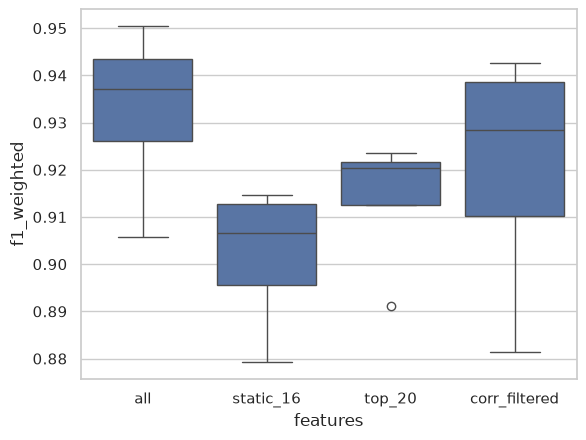

In [39]:
sns.boxplot(data=scenariowise_perf_df, x='features', y='f1_weighted')